# Three-Sector Model with Michaelis-Menten Kinetics
Analyzed under translational inhibition $a_2$.

------------------------------
Running analysis for varying a2...
Starting optimization for varying a2 (0.01 to 1000) with fixed b=10...
Optimization completed in 2.73 seconds.


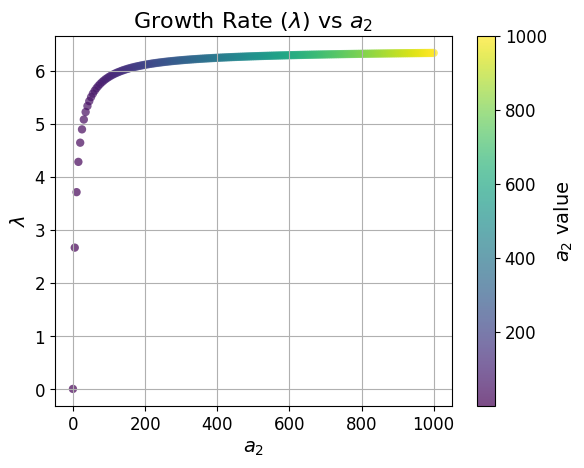

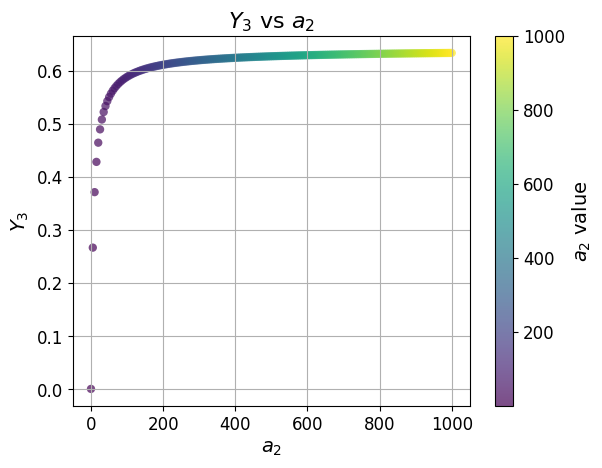

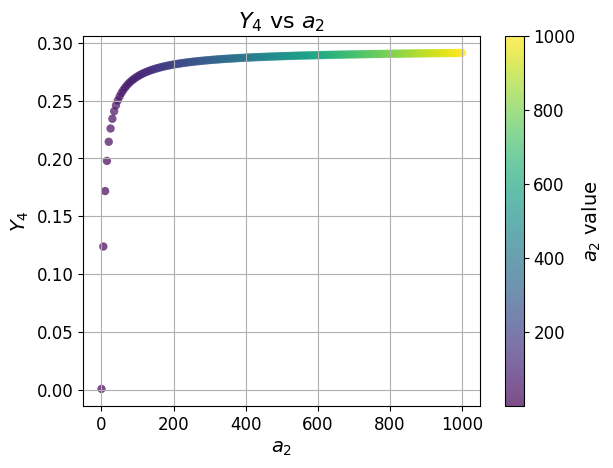

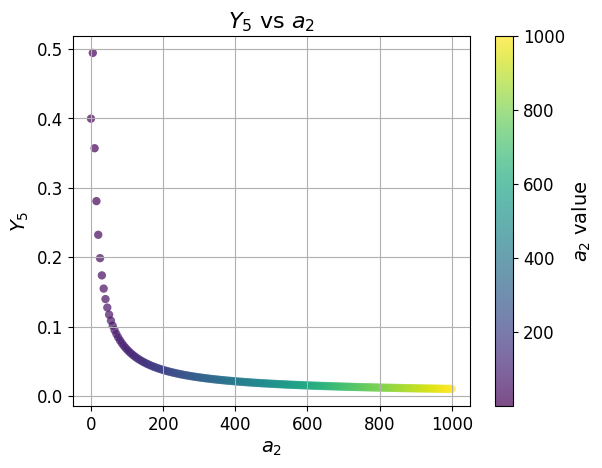

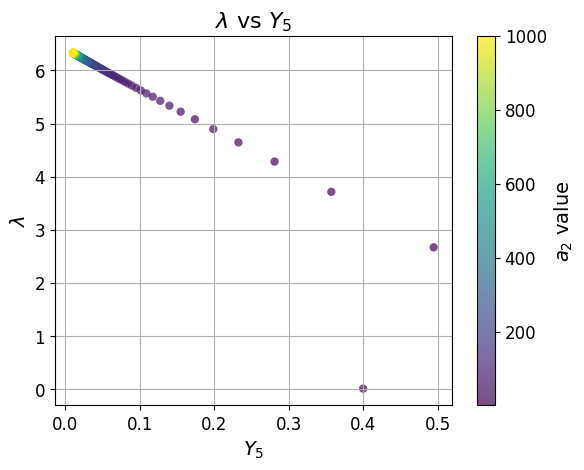

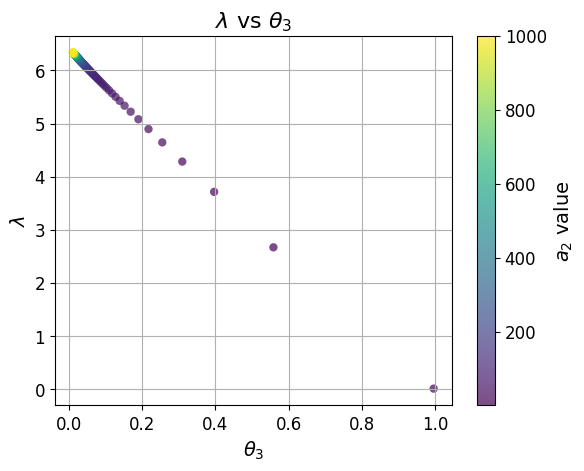

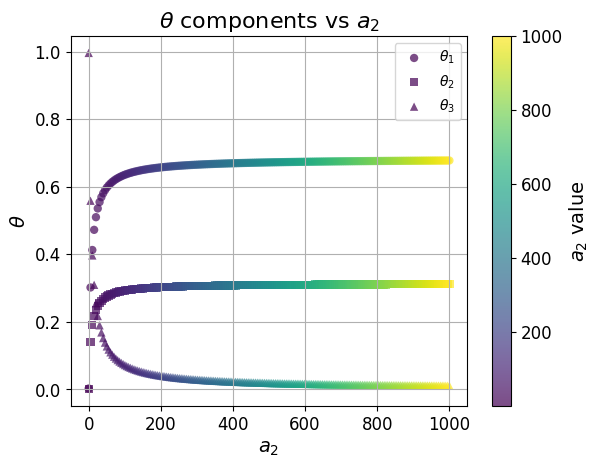

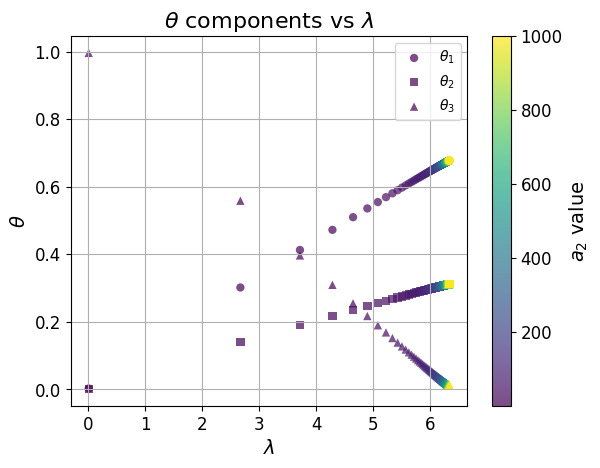

In [1]:
# --- Analysis with varying a2 ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import logsumexp
from joblib import Parallel, delayed
import time

print("-" * 30)
print("Running analysis for varying a2...")

# Constants for this analysis
a1 = 23.8
# a2 will vary
k1, k2 = 0.01, 0.003
N = 200
label_size = 14
title_size = 16
tick_size = 12

a2_min, a2_max = 0.01, 1000
b_fixed = 10
a2_vals = np.linspace(a2_min, a2_max, N)

# Helper function
def softmax_partition(u):
    u1, u2 = u
    logZ = logsumexp([u1, 0.0, u2])
    theta1 = np.exp(u1 - logZ)
    theta2 = np.exp(-logZ)
    theta3 = np.exp(u2 - logZ)
    return theta1, theta2, theta3

# Redefine system to accept varying a2
def BioSystemMM3_var_a2(theta, b_val, current_a2):
    # theta = [theta1, theta2, theta3]
    b_val = max(b_val, 1e-6) # Numerical safety: prevent division by zero or near-zero b
    term_Y1 = (a1 * theta[1]) / (b_val * theta[0]) + k1 - 1
    Y1 = 0.5 * (np.sqrt(term_Y1**2 + 4 * k1) - term_Y1)
    
    term_Y2 = (current_a2 * theta[2]) / (b_val * theta[0]) + k2 - (1 - Y1)
    Y2 = 0.5 * (np.sqrt(term_Y2**2 + 4 * (1 - Y1) * k2) - term_Y2)
    
    Y3 = (current_a2 * theta[2] / b_val) * (Y2 / (k2 + Y2))
    Y4 = (current_a2 * theta[1] * theta[2] / (b_val * theta[0])) * (Y2 / (k2 + Y2))
    Y5 = (current_a2 * theta[2]**2 / (b_val * theta[0])) * (Y2 / (k2 + Y2))
    
    lambda_val = b_val * Y3
    
    # Correction in r_denom usage of a2
    r_denom = ((k1 + Y1) / (a1 * Y4)) + ((k2 + Y2) / (current_a2 * Y5))
    r_avg = 1 / r_denom if r_denom != 0 else np.nan
    
    return np.array([b_val, theta[0], theta[1], theta[2], Y1, Y2, Y3, Y4, Y5, lambda_val, r_avg])

def objective_softmax_var_a2(u, b_val, current_a2):
    return -BioSystemMM3_var_a2(softmax_partition(u), b_val, current_a2)[9]

def optimize_for_a2(current_a2, tol=1e-6, maxiter=1000):
   # Optimization similar to optimize_for_b_softmax but varying a2
    result = minimize(
        lambda u: objective_softmax_var_a2(u, b_fixed, current_a2),
        x0=[0.0, 0.0],
        method='Powell', # Using Powell as it was robust for smaller b
        tol=tol,
        options={'xtol': tol, 'ftol': tol, 'maxiter': maxiter, 'disp': False}
    )
    
    if result.success:
        return BioSystemMM3_var_a2(softmax_partition(result.x), b_fixed, current_a2)
    
    # Fallback
    result_retry = minimize(
        lambda u: objective_softmax_var_a2(u, b_fixed, current_a2),
        x0=result.x,
        method='Nelder-Mead',
        tol=tol,
        options={'maxiter': maxiter, 'disp': False}
    )
    return BioSystemMM3_var_a2(softmax_partition(result_retry.x), b_fixed, current_a2)

# Run optimization
print(f"Starting optimization for varying a2 ({a2_min} to {a2_max}) with fixed b={b_fixed}...")
start_time = time.time()
results_a2 = Parallel(n_jobs=-1)(delayed(optimize_for_a2)(a2_val) for a2_val in a2_vals)
results_a2 = np.array(results_a2)
print(f"Optimization completed in {time.time() - start_time:.2f} seconds.")

# Unpack results
(b_const, theta1_a2, theta2_a2, theta3_a2, 
 Y1_a2, Y2_a2, Y3_a2, Y4_a2, Y5_a2, 
 lambda_a2, r_avg_a2) = results_a2.T

# Plotting
# (1) lambda vs a2
plt.figure()
scatter = plt.scatter(a2_vals, lambda_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label(r'$a_2$ value', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)
plt.xlabel(r'$a_2$', fontsize=label_size)
plt.ylabel(r'$\lambda$', fontsize=label_size)
plt.title(r'Growth Rate ($\lambda$) vs $a_2$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True)
plt.show()

# (2) Y3 vs a2
plt.figure()
scatter = plt.scatter(a2_vals, Y3_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label(r'$a_2$ value', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)
plt.xlabel(r'$a_2$', fontsize=label_size)
plt.ylabel(r'$Y_3$', fontsize=label_size)
plt.title(r'$Y_3$ vs $a_2$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True)
plt.show()

# (3) Y4 vs a2
plt.figure()
scatter = plt.scatter(a2_vals, Y4_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label(r'$a_2$ value', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)
plt.xlabel(r'$a_2$', fontsize=label_size)
plt.ylabel(r'$Y_4$', fontsize=label_size)
plt.title(r'$Y_4$ vs $a_2$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True)
plt.show()

# (4) Y5 vs a2
plt.figure()
scatter = plt.scatter(a2_vals, Y5_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label(r'$a_2$ value', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)
plt.xlabel(r'$a_2$', fontsize=label_size)
plt.ylabel(r'$Y_5$', fontsize=label_size)
plt.title(r'$Y_5$ vs $a_2$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True)
plt.show()

# (5) lambda vs Y5
plt.figure()
scatter = plt.scatter(Y5_a2, lambda_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label(r'$a_2$ value', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)
plt.xlabel(r'$Y_5$', fontsize=label_size)
plt.ylabel(r'$\lambda$', fontsize=label_size)
plt.title(r'$\lambda$ vs $Y_5$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True)
plt.show()

# (6) lambda vs theta3
plt.figure()
scatter = plt.scatter(theta3_a2, lambda_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label(r'$a_2$ value', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)
plt.xlabel(r'$\theta_3$', fontsize=label_size)
plt.ylabel(r'$\lambda$', fontsize=label_size)
plt.title(r'$\lambda$ vs $\theta_3$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True)
plt.show()

# (7) theta1, theta2, theta3 vs a2
plt.figure()
scatter1 = plt.scatter(a2_vals, theta1_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7, marker='o', label=r'$\theta_1$')
scatter2 = plt.scatter(a2_vals, theta2_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7, marker='s', label=r'$\theta_2$')
scatter3 = plt.scatter(a2_vals, theta3_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7, marker='^', label=r'$\theta_3$')
cbar = plt.colorbar(scatter1)
cbar.set_label(r'$a_2$ value', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)
plt.xlabel(r'$a_2$', fontsize=label_size)
plt.ylabel(r'$\theta$', fontsize=label_size)
plt.title(r'$\theta$ components vs $a_2$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.legend()
plt.grid(True)
plt.show()

# (8) theta1, theta2, theta3 vs lambda
plt.figure()
scatter1 = plt.scatter(lambda_a2, theta1_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7, marker='o', label=r'$\theta_1$')
scatter2 = plt.scatter(lambda_a2, theta2_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7, marker='s', label=r'$\theta_2$')
scatter3 = plt.scatter(lambda_a2, theta3_a2, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7, marker='^', label=r'$\theta_3$')
cbar = plt.colorbar(scatter1)
cbar.set_label(r'$a_2$ value', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)
plt.xlabel(r'$\lambda$', fontsize=label_size)
plt.ylabel(r'$\theta$', fontsize=label_size)
plt.title(r'$\theta$ components vs $\lambda$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.legend()
plt.grid(True)
plt.show()

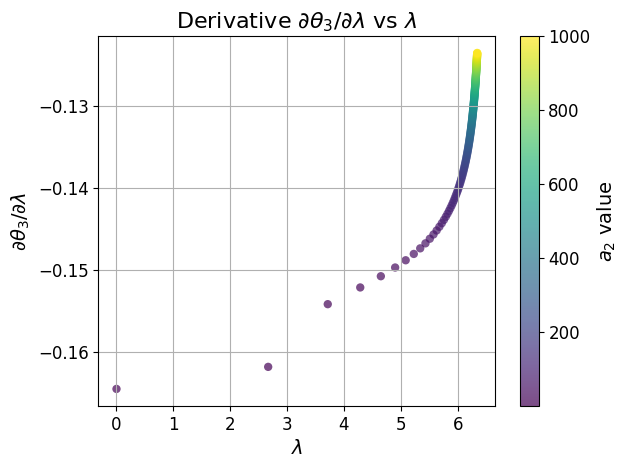

In [2]:
# --- Derivative Analysis: d(theta3)/d(lambda) ---
# Calculate numeric derivatives d(theta3)/d(lambda) using the data from varying a2
# Since both theta3 and lambda are functions of a2, we use d(theta3)/d(lam) = (d(theta3)/da2) / (d(lam)/da2)

d_theta3_da2 = np.gradient(theta3_a2, a2_vals)
d_lambda_da2 = np.gradient(lambda_a2, a2_vals)

# Avoid division by very small values to prevent numerical artifacts
d_theta3_d_lambda = np.divide(d_theta3_da2, d_lambda_da2, out=np.zeros_like(d_theta3_da2), where=np.abs(d_lambda_da2) > 1e-9)

# (10) Derivative vs lambda
plt.figure()
scatter = plt.scatter(lambda_a2, d_theta3_d_lambda, c=a2_vals, cmap='viridis', edgecolors='none', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label(r'$a_2$ value', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)
plt.xlabel(r'$\lambda$', fontsize=label_size)
plt.ylabel(r'$\partial \theta_3 / \partial \lambda$', fontsize=label_size)
plt.title(r'Derivative $\partial \theta_3 / \partial \lambda$ vs $\lambda$', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True)
plt.show()

Starting optimization for 2601 grid points...
Contour optimization completed in 6.85 seconds.


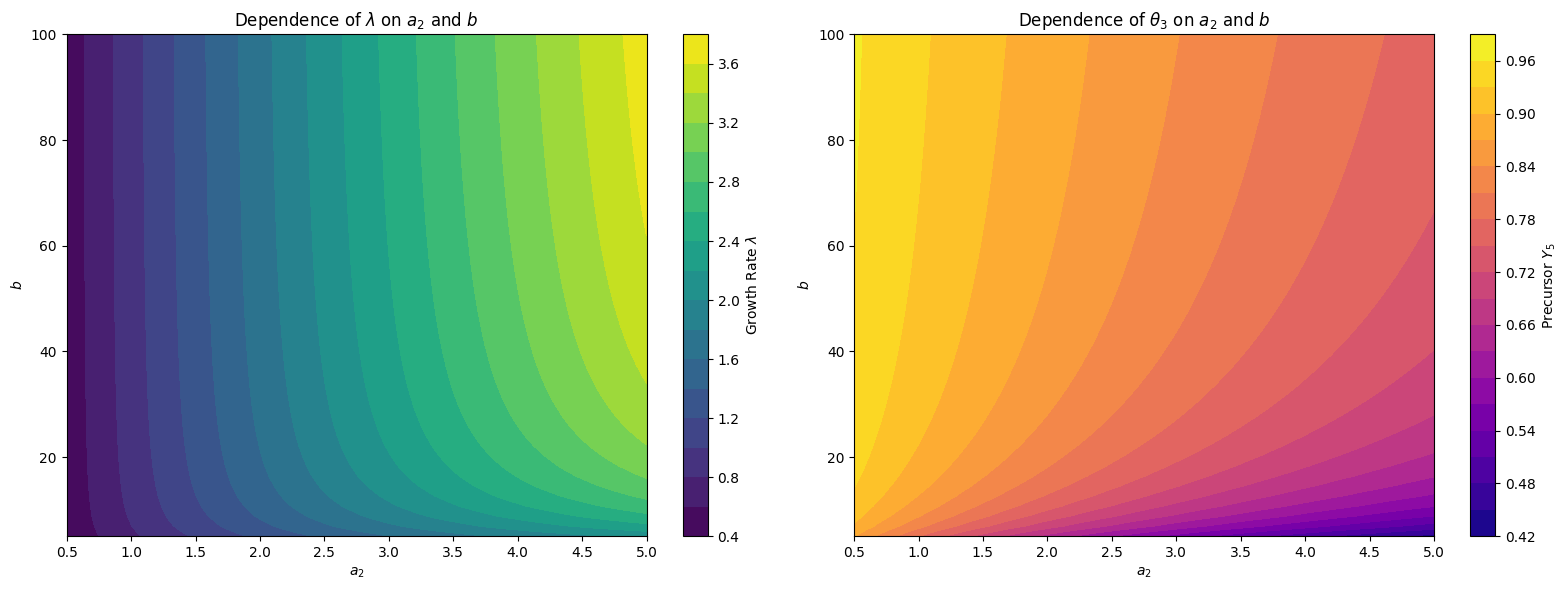

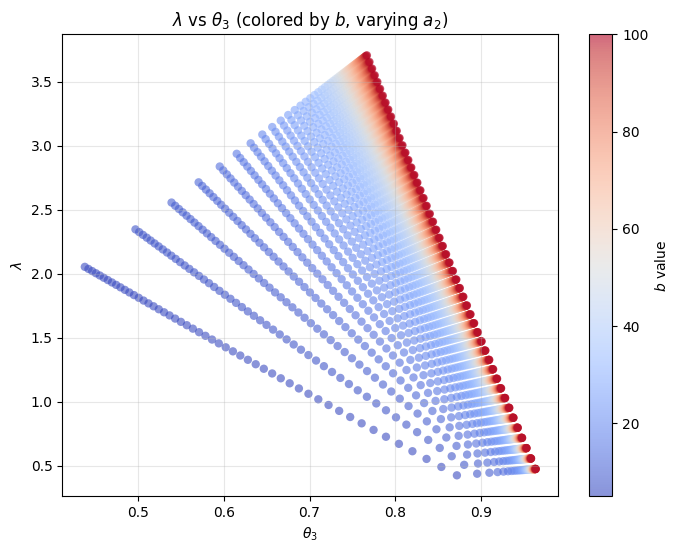

In [5]:
# --- Contour Analysis: Varying both a2 and b ---

# Define ranges
N_grid = 50  # Grid resolution
a2_min_c, a2_max_c = 0.5, 5
b_min_c, b_max_c = 5, 100 # Minimum b set to 5 to avoid non-biological zero values

a2_grid = np.linspace(a2_min_c, a2_max_c, N_grid+1)
b_grid = np.linspace(b_min_c, b_max_c, N_grid+1)
A2, B = np.meshgrid(a2_grid, b_grid)

# Wrapper for optimization with both a2 and b variable
# Note: Relies on BioSystemMM3_var_a2 and objective_softmax_var_a2 from previous cell
def optimize_for_a2_b(current_a2, current_b, tol=1e-6, maxiter=1000):
     # Objective function closing over current_b and current_a2
    def obj(u):
        return objective_softmax_var_a2(u, current_b, current_a2)

    # First attempt: Powell
    result = minimize(
        obj,
        x0=[0.0, 0.0],
        method='Powell',
        tol=tol,
        options={'xtol': tol, 'ftol': tol, 'maxiter': maxiter, 'disp': False}
    )
    
    if result.success:
        return BioSystemMM3_var_a2(softmax_partition(result.x), current_b, current_a2)
    
    # Fallback: Nelder-Mead
    result_retry = minimize(
        obj,
        x0=result.x,
        method='Nelder-Mead',
        tol=tol,
        options={'maxiter': maxiter, 'disp': False}
    )
    return BioSystemMM3_var_a2(softmax_partition(result_retry.x), current_b, current_a2)

# Flatten for parallel execution
params_list = [(a2, b) for a2, b in zip(A2.ravel(), B.ravel())]

print(f"Starting optimization for {len(params_list)} grid points...")
start_time_c = time.time()
results_contour = Parallel(n_jobs=-1)(delayed(optimize_for_a2_b)(a2, b) for a2, b in params_list)
print(f"Contour optimization completed in {time.time() - start_time_c:.2f} seconds.")

results_contour = np.array(results_contour)

# BioSystemMM3_var_a2 returns: [b_val, theta1, theta2, theta3, Y1, Y2, Y3, Y4, Y5, lambda_val, r_avg]
lambda_flat = results_contour[:, 9]
theta3_flat = results_contour[:, 3]

# Reshape
lambda_grid = lambda_flat.reshape(A2.shape)
theta3_grid = theta3_flat.reshape(A2.shape)

# Plotting

# 1. Dual Contour Plots (Dependence on a2 and b)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1a: Lambda Contour
cp1 = axes[0].contourf(A2, B, lambda_grid, levels=20, cmap='viridis')
fig.colorbar(cp1, ax=axes[0], label=r'Growth Rate $\lambda$')
axes[0].set_xlabel(r'$a_2$')
axes[0].set_ylabel(r'$b$')
axes[0].set_title(r'Dependence of $\lambda$ on $a_2$ and $b$')

# Plot 1b: Y5 Contour
cp2 = axes[1].contourf(A2, B, theta3_grid, levels=20, cmap='plasma')
fig.colorbar(cp2, ax=axes[1], label=r'Precursor $Y_5$')
axes[1].set_xlabel(r'$a_2$')
axes[1].set_ylabel(r'$b$')
axes[1].set_title(r'Dependence of $\theta_3$ on $a_2$ and $b$')

plt.tight_layout()
plt.show()

# 2. Scatter/Correlation Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(theta3_flat, lambda_flat, c=B.ravel(), cmap='coolwarm', alpha=0.6, edgecolors='none')
cbar = plt.colorbar(sc)
cbar.set_label(r'$b$ value')
plt.xlabel(r'$\theta_3$')
plt.ylabel(r'$\lambda$')
plt.title(r'$\lambda$ vs $\theta_3$ (colored by $b$, varying $a_2$)')
plt.grid(True, alpha=0.3)
plt.show()

------------------------------
Running discrete optimization for 10x10 grid...


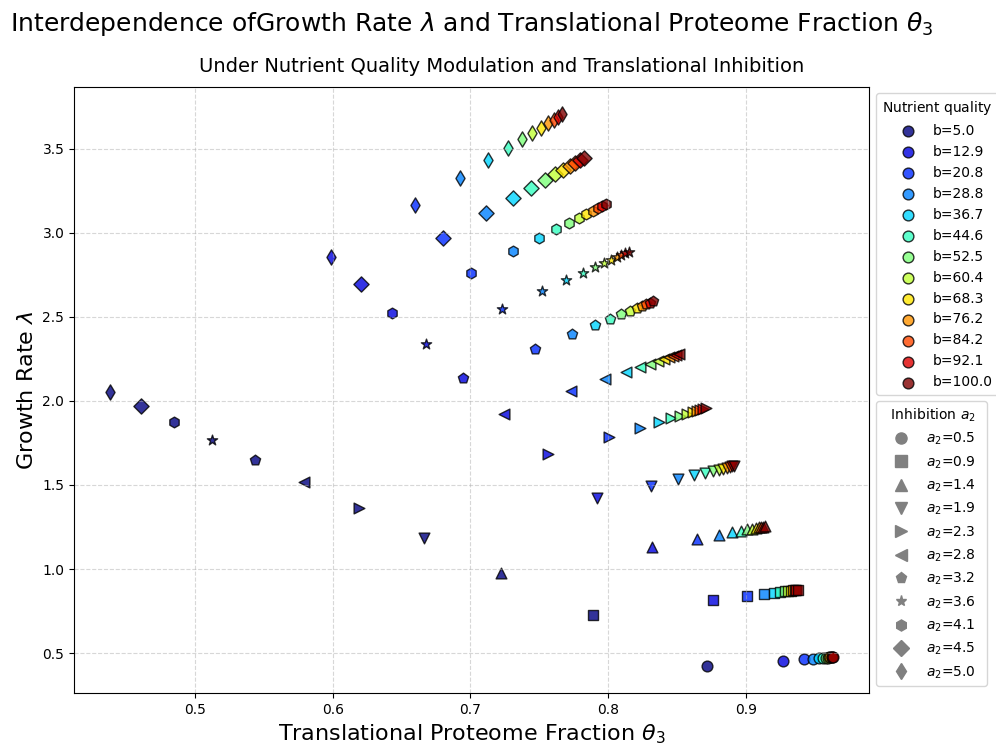

In [7]:
# --- Discrete Grid Analysis: 10x10 combinations of b and a2 ---

print("-" * 30)
print("Running discrete optimization for 10x10 grid...")

# Define smaller grid (10x10)
N_a2 = 10
N_b = 12
a2_10 = np.linspace(a2_min_c, a2_max_c, N_a2+1)
b_10 = np.linspace(b_min_c, b_max_c, N_b+1)

# Run optimization for all 100 points
results_10x10 = []
for b_val in b_10:
    row = Parallel(n_jobs=-1)(delayed(optimize_for_a2_b)(a2_val, b_val) for a2_val in a2_10)
    results_10x10.append(row)

results_10x10 = np.array(results_10x10) # Shape (N_b+1, N_a2+1, 11)

# markers for each a2 value
markers = ['o', 's', '^', 'v', '>', '<', 'p', '*', 'h', 'D', 'd', '1', '2', '3', '4', '+', 'x', 'X', 'P', '8', 'H']
# colors for each b value (using a colormap)
colors = plt.cm.jet(np.linspace(0, 1, N_b+1))

plt.figure(figsize=(10, 8))

for i, b_val in enumerate(b_10):
    for j, a2_val in enumerate(a2_10):
        # results_10x10[i, j] matches b_10[i] and a2_10[j]
        # index 3 is theta3, index 9 is lambda
        th3 = results_10x10[i, j, 3]
        lam = results_10x10[i, j, 9]
        
        # Only add label once for the legend
        label = f'b={b_val:.1f}' if j == 0 else ""
        
        plt.scatter(th3, lam, 
                    color=colors[i], 
                    marker=markers[j], 
                    s=60, 
                    alpha=0.8,
                    edgecolors='black',
                    label=label)

# Add custom legend for markers (a2 values)
from matplotlib.lines import Line2D
marker_legend_elements = [Line2D([0], [0], marker=markers[j], color='gray', linestyle='None',
                                 label=f'$a_2$={a2_10[j]:.1f}', markersize=8) for j in range(len(a2_10))]

# First legend (b values)
leg1 = plt.legend(title="Nutrient quality $b$", loc='upper left', bbox_to_anchor=(1, 1))
# Second legend (a2 values)
plt.gca().add_artist(leg1)
plt.legend(handles=marker_legend_elements, title="  Inhibition $a_2$  ", loc='lower left', bbox_to_anchor=(1, 0))

plt.title(r'Interdependence ofGrowth Rate $\lambda$ and Translational Proteome Fraction $\theta_3$', fontsize=18, pad=40)
plt.suptitle("Under Nutrient Quality Modulation and Translational Inhibition", fontsize=14, y=0.88)
plt.xlabel(r'Translational Proteome Fraction $\theta_3$', fontsize=16)
plt.ylabel(r'Growth Rate $\lambda$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()